# Hierarchical Clustering — An Illustrated Tour

> Build a **tree** of clusters, either by **agglomerating** (bottom-up) singletons or **dividing** the whole dataset (top-down). Cut the tree at any height to read off a clustering.

---

**What we cover:**
- Agglomerative algorithm — merge the closest pair until one cluster remains
- Linkage functions — single, complete, average, Ward
- The dendrogram — read it like a phylogenetic tree
- Cutting the tree to get a clustering
- How linkage shapes the clusters

## The picture — dendrogram: a tree of merges; cut at any height for k clusters

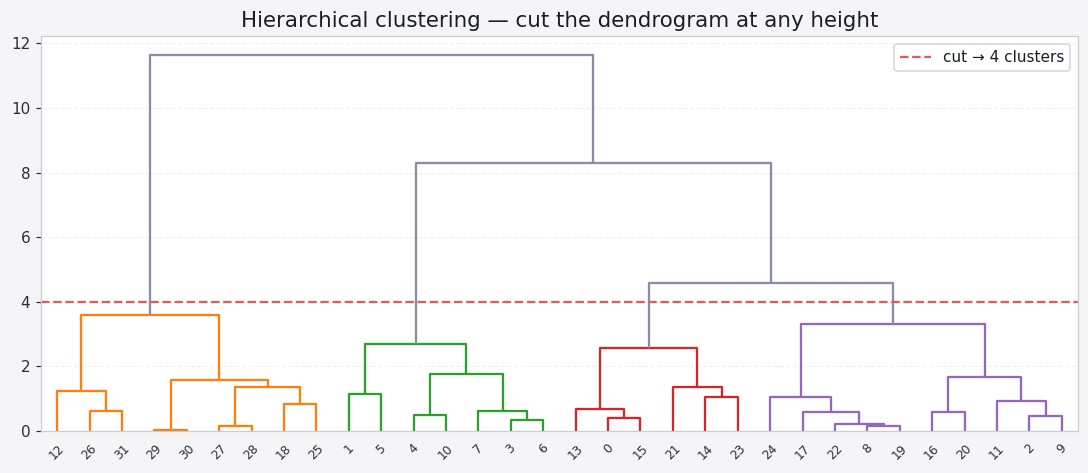

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
from scipy.cluster.hierarchy import linkage, dendrogram
X = np.vstack([rng.randn(8,2)+[i,0] for i in [-2,0,2,4]])
Z = linkage(X, 'ward')
fig, ax = plt.subplots(figsize=(10, 4.4))
dendrogram(Z, ax=ax, color_threshold=4.0,
           above_threshold_color='#888fa5')
ax.axhline(4.0, color=P[1], ls='--', lw=1.5, label='cut → 4 clusters')
ax.set_title('Hierarchical clustering — cut the dendrogram at any height')
ax.legend(); ax.grid(True, axis='y'); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs, make_moons

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'
PALETTE = [C0, C1, CB, CM, CH, CP]

rng = np.random.default_rng(0)
X, y_true = make_blobs(n_samples=60, centers=4, cluster_std=0.7, random_state=7)
X_big, _  = make_blobs(n_samples=180, centers=4, cluster_std=0.7, random_state=7)
print('Small set for dendrogram:', X.shape)

Small set for dendrogram: (60, 2)


---
## Agglomerative — Bottom-Up Merging

Start: every point is its own cluster.
Repeat: merge the two closest clusters according to a **linkage** rule, until one cluster remains.

The four classical linkages, given two clusters $A$ and $B$:

| Linkage | Distance $d(A, B)$ | Tendency |
|---|---|---|
| **Single** | $\min_{a\in A, b\in B} \|a - b\|$ | Chaining — long thin clusters |
| **Complete** | $\max_{a\in A, b\in B} \|a - b\|$ | Tight, compact, similar-size |
| **Average** | mean pairwise distance | Compromise |
| **Ward** | increase in within-cluster SS | Similar to K-Means; spherical |

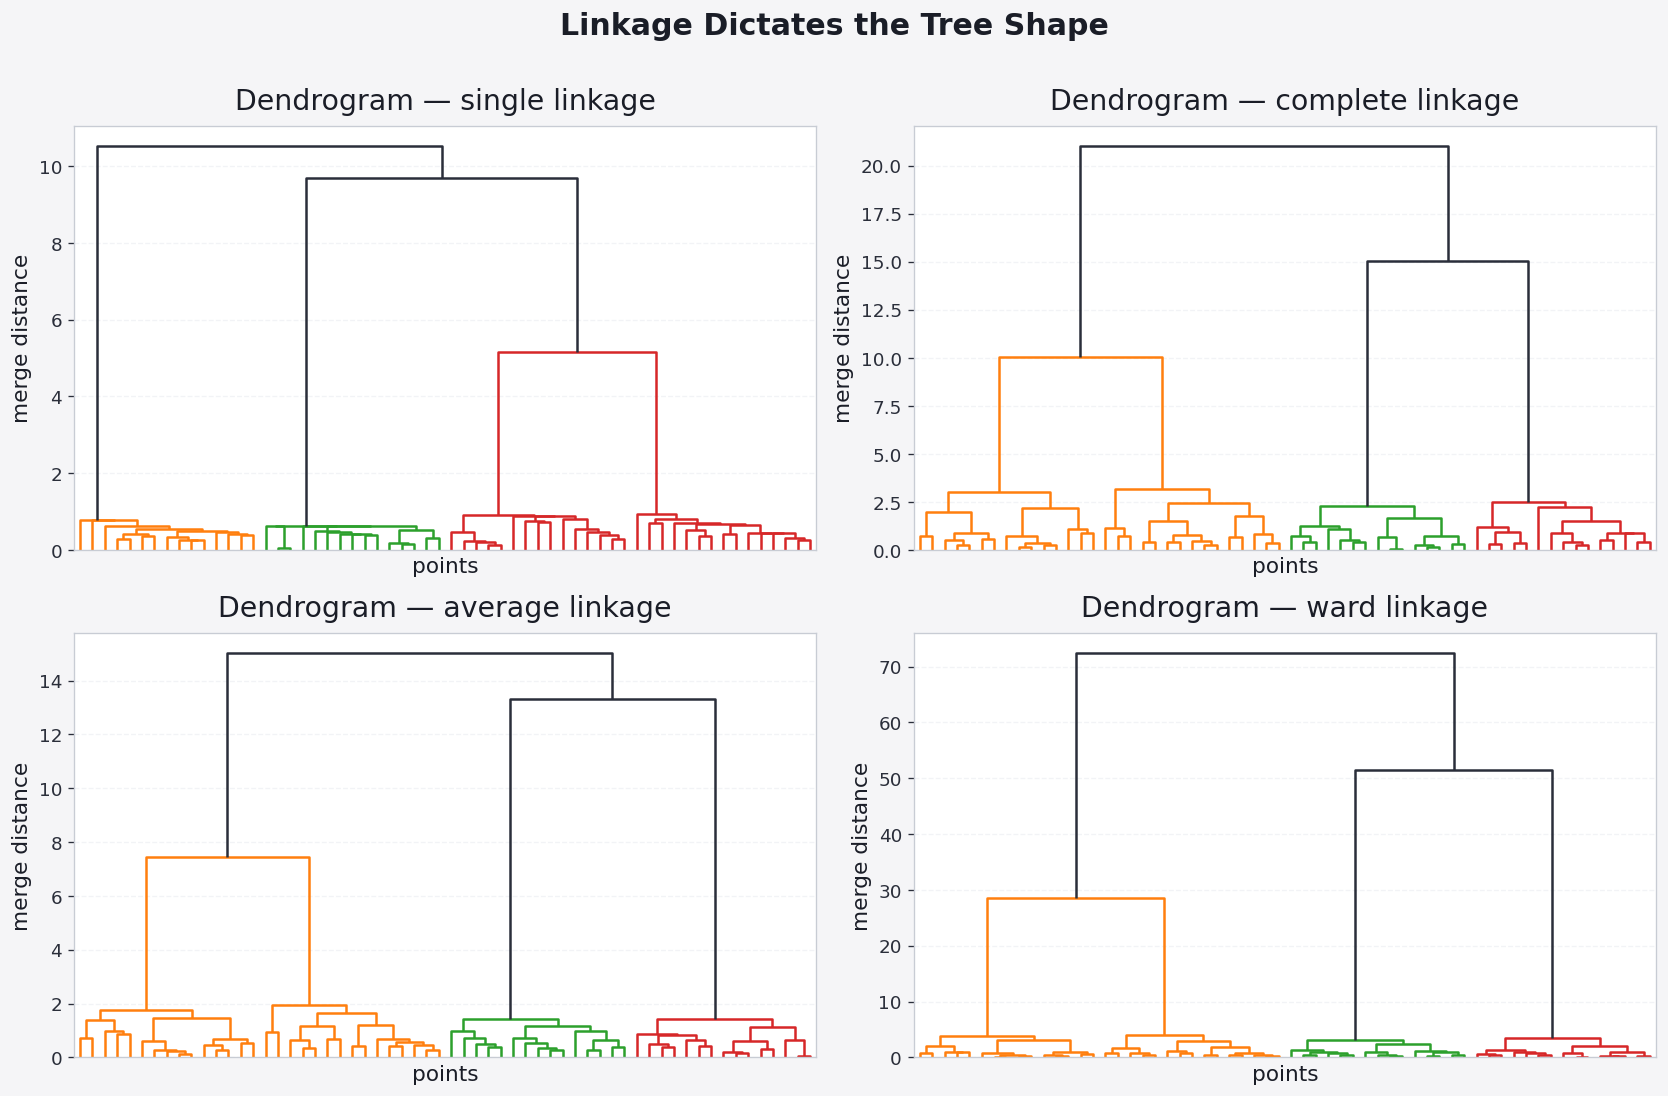

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, link in zip(axes.flat, ['single', 'complete', 'average', 'ward']):
    Z = linkage(X, method=link)
    dendrogram(Z, ax=ax, color_threshold=0.5*max(Z[:,2]),
               above_threshold_color='#2a2e3a')
    ax.set_title(f'Dendrogram — {link} linkage', pad=10)
    ax.set_xlabel('points'); ax.set_ylabel('merge distance')
    ax.set_xticks([])
    ax.grid(True, axis='y', alpha=0.4)
fig.suptitle('Linkage Dictates the Tree Shape', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Cutting the Tree

A horizontal cut at height $h$ in the dendrogram intersects $k$ branches — you get $k$ clusters. Cut low to get many small clusters; cut high for few large ones. **`fcluster(Z, t=k, criterion='maxclust')`** picks $k$ for you.

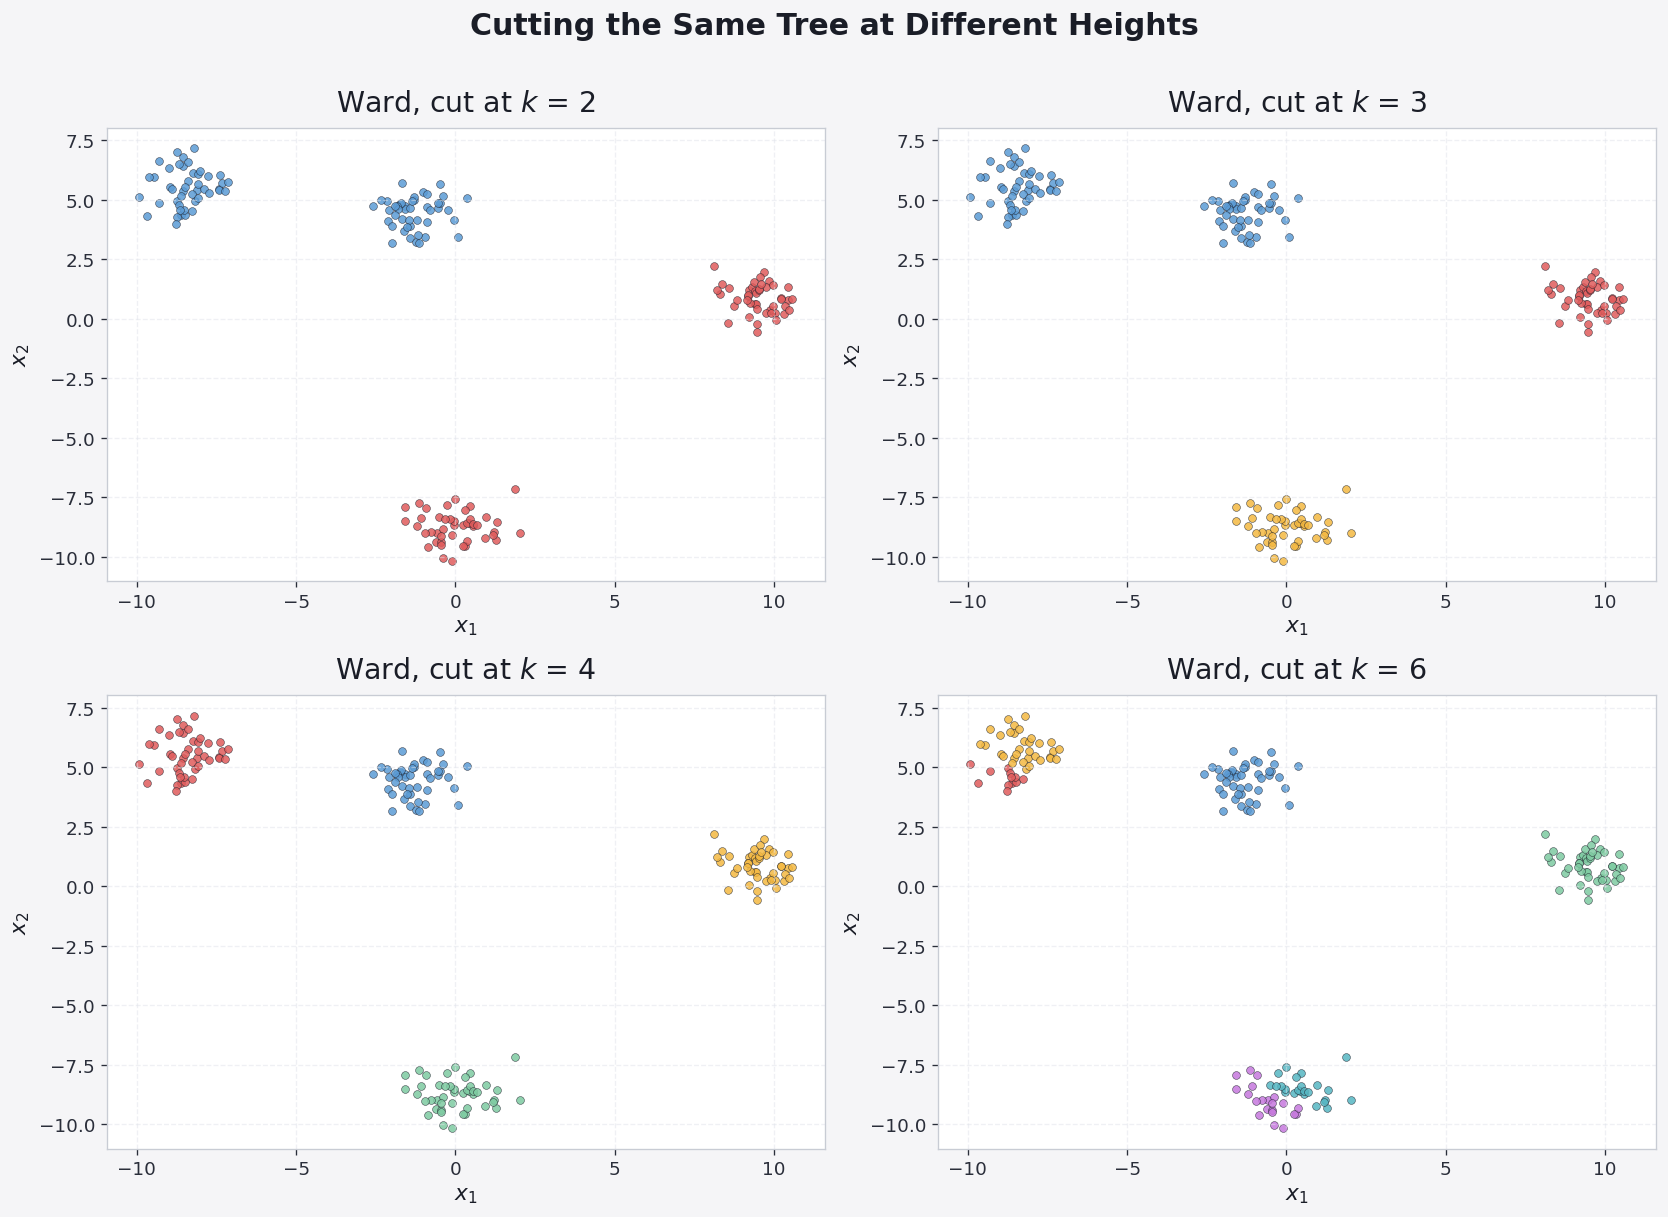

In [4]:
Z = linkage(X_big, method='ward')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, k in zip(axes.flat, [2, 3, 4, 6]):
    lbl = fcluster(Z, t=k, criterion='maxclust') - 1
    for j in range(lbl.max()+1):
        m = lbl == j
        ax.scatter(X_big[m,0], X_big[m,1], c=PALETTE[j%len(PALETTE)],
                   s=22, edgecolors='#1a1d27', lw=0.3, alpha=0.85)
    ax.set_title(f'Ward, cut at $k$ = {k}', pad=10)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)
fig.suptitle('Cutting the Same Tree at Different Heights', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## How Linkage Reshapes the Result

On non-convex data, the linkage choice changes everything. **Single** linkage walks along the manifold (good for moons but creates chains). **Ward** behaves like K-Means and breaks the moons in half.

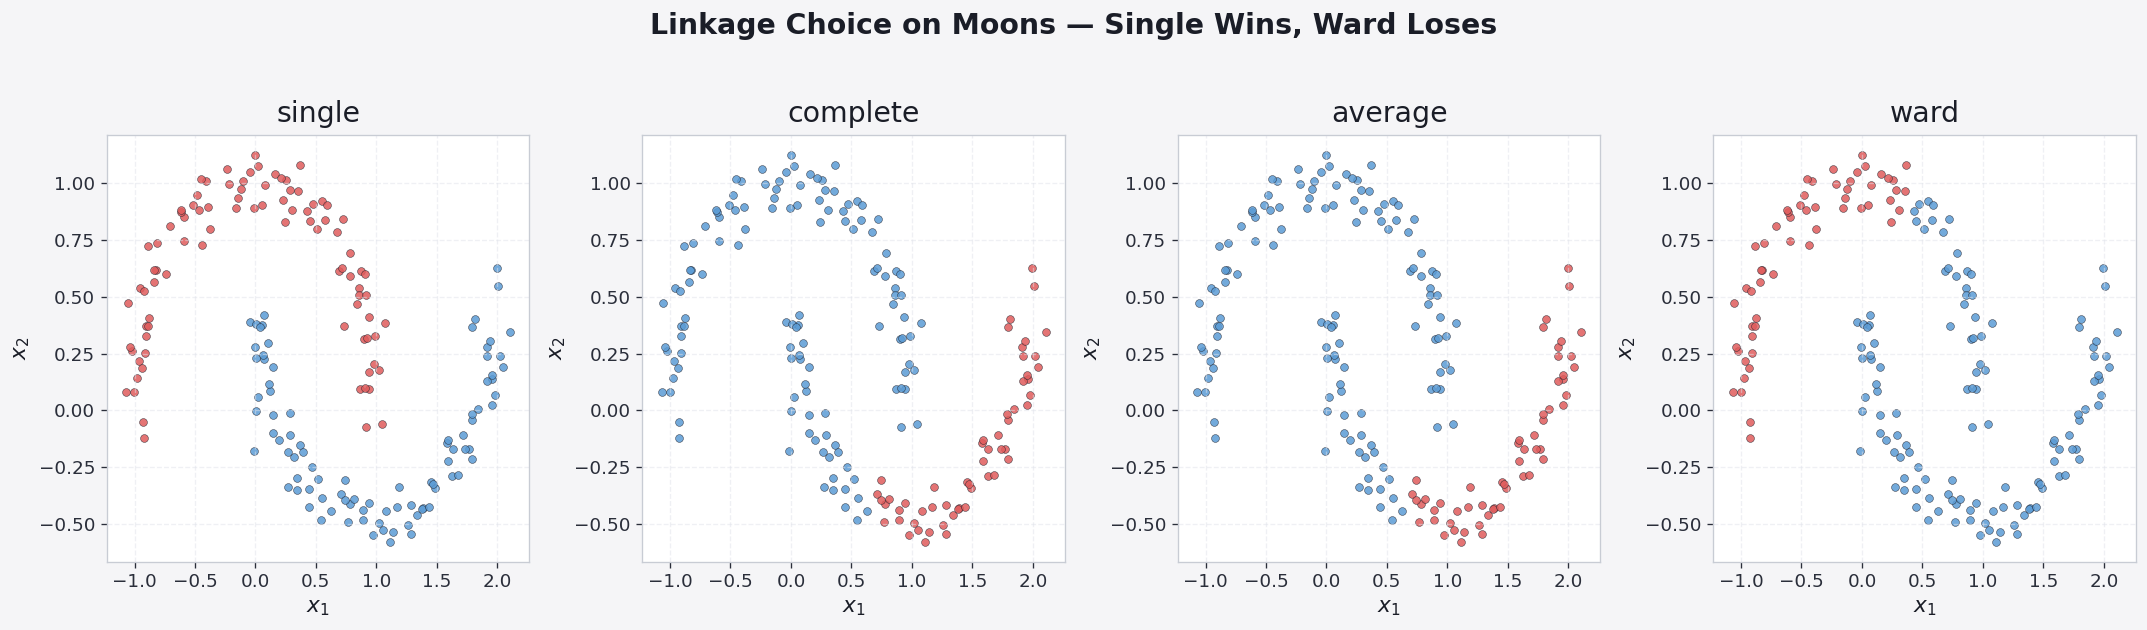

In [5]:
Xm, _ = make_moons(n_samples=180, noise=0.07, random_state=0)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, link in zip(axes, ['single', 'complete', 'average', 'ward']):
    lbl = AgglomerativeClustering(n_clusters=2, linkage=link).fit_predict(Xm)
    for j in range(2):
        m = lbl == j
        ax.scatter(Xm[m,0], Xm[m,1], c=PALETTE[j], s=22, edgecolors='#1a1d27', lw=0.3, alpha=0.85)
    ax.set_title(f'{link}', pad=8); ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)
fig.suptitle('Linkage Choice on Moons — Single Wins, Ward Loses', fontsize=17, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

---
## ⚖️ When to use hierarchical clustering — and when not to

| Situation | Hierarchical | K-Means | DBSCAN |
|---|---|---|---|
| Don't know $k$ — want a tree | ✅ | ❌ | partial |
| Very large $n$ ($>50\,000$) | ❌ $O(n^2)$ memory | ✅ | partial |
| Non-globular shapes | ✅ single linkage | ❌ | ✅ |
| Need stable, deterministic output | ✅ | ❌ depends on init | ✅ |

> Use hierarchical clustering for **exploratory analysis** when you want to *see* the structure at multiple scales.


---
## 🎯 Try this

1. **Read the dendrogram.** Identify the largest vertical gap in a Ward dendrogram — that height is a natural cut-point. Compare to silhouette-recommended $k$.
2. **Cophenetic correlation.** Compute the cophenetic correlation coefficient for each linkage method. Higher = the dendrogram preserves the original distances better.
3. **Linkage on moons.** Apply single, complete and Ward linkage to two interlocking moons. Only single linkage finds the right two clusters; explain why.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Agglomerative | Bottom-up merging | $O(n^2 \log n)$ — fine up to ~10k points |
| Single | Min-distance link | Chains; finds elongated shapes |
| Complete | Max-distance link | Tight, compact, equal-sized |
| Average | Mean-distance link | Robust compromise |
| Ward | Minimise SS increase | Mimics K-Means; spherical clusters |
| Dendrogram | Tree of merges | Cut at any height for any $k$ |
| Strength | Multi-resolution; no $k$ in advance | Great when hierarchy matters (taxonomies, gene expression) |
| Weakness | Quadratic memory; can't undo a merge | Bad on huge datasets |

**Bottom line:** Hierarchical clustering hands you a **whole family of clusterings at once** in the form of a tree. The linkage rule decides whether the tree captures shape (single) or shape-free compactness (Ward).